<a href="https://colab.research.google.com/github/darjiavani/college-website/blob/main/transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from operator import xor
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.datasets import cifar10

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

x_train = tf.image.resize(x_train, (96, 96))
x_test = tf.image.resize(x_test, (96, 96))

y_train = y_train.squeeze()
y_test = y_test.squeeze()

base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(96, 96, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history = model.fit(x_train, y_train, epochs=2, batch_size=64, validation_data=(x_test, y_test))







Epoch 1/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 407s 513ms/step - accuracy: 0.4261 - loss: 1.6209 - val_accuracy: 0.4690 - val_loss: 1.4916
Epoch 2/2
782/782 ━━━━━━━━━━━━━━━━━━━━ 385s 492ms/step - accuracy: 0.4928 - loss: 1.4321 - val_accuracy: 0.4876 - val_loss: 1.4435


79/79 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step

sklearn Accuracy: 0.4864

Classification Report:

              precision    recall  f1-score   support

    airplane       0.66      0.45      0.54      1000
  automobile       0.62      0.46      0.52      1000
        bird       0.46      0.35      0.40      1000
         cat       0.36      0.22      0.27      1000
        deer       0.55      0.37      0.44      1000
         dog       0.33      0.59      0.43      1000
        frog       0.65      0.56      0.60      1000
       horse       0.48      0.58      0.52      1000
        ship       0.65      0.52      0.58      1000
       truck       0.41      0.76      0.53      1000

    accuracy                           0.49     10000
   macro avg       0.52      0.49      0.48     10000
weighted avg       0.52      0.49      0.48     10000



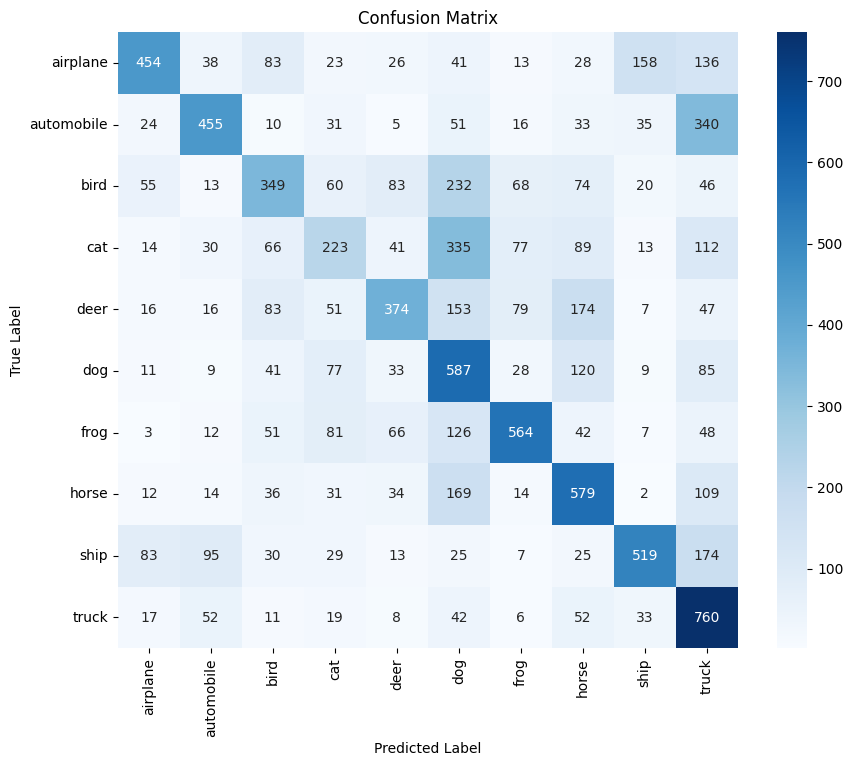

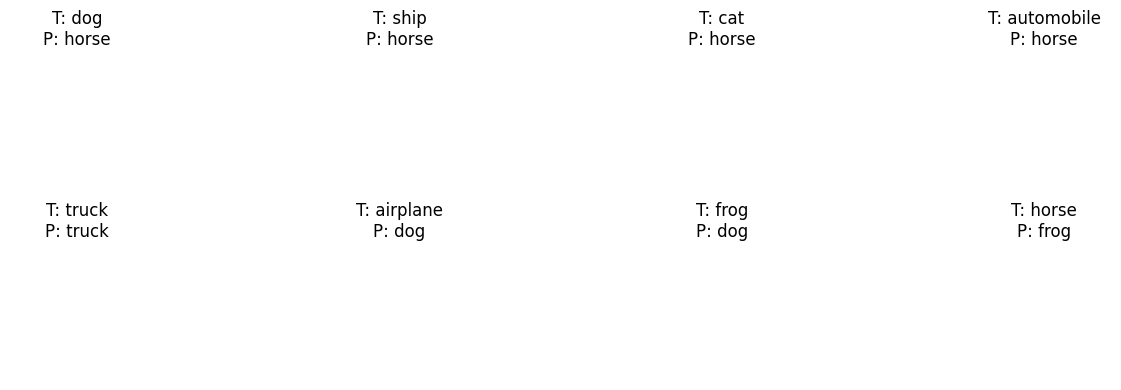

In [5]:
probs = model.predict(x_test, batch_size=128)
y_pred = np.argmax(probs, axis=1)

print("\nsklearn Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))


import seaborn as sns
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

n = 8
idxs = np.random.choice(len(x_test), n, replace=False)


plt.figure(figsize=(14, 4))
for i, idx in enumerate(idxs):
    plt.subplot(2, 4, i+1)
    # x_test is a tensor; convert to numpy for plotting
    plt.imshow(x_test[idx].numpy())
    true_label = class_names[y_test[idx]]
    pred_label = class_names[y_pred[idx]]
    plt.title(f"T: {true_label}\nP: {pred_label}")
    plt.axis("off")


plt.tight_layout()
plt.show()
